# The Full Bucket Model: Snow, Soil, and Groundwater

In this notebook we assemble the full bucket model for Alamedin. We already have the linear reservoir from notebook 07 — this is the piece that will become the groundwater store. Everything else (snow on top, soil in the middle) we build in this notebook and then wire together.

By the end of the notebook, you should be able to:

- extend a `@dataclass` from one field (notebook 07) to several fields without changing how you read the code
- describe the three buckets of the model (snow, soil, groundwater) and what each one stores
- write a precipitation-partitioning rule that decides rain vs. snow from daily temperature
- implement the degree-day snowmelt equation and explain why it is zero on frozen days
- load the pre-computed daily forcing saved at the end of notebook 05 (precipitation, temperature, PET)
- write a soil-moisture-limited evapotranspiration function and show how it collapses to PET at field capacity
- write a saturation-excess soil bucket that returns new soil, surface runoff, and percolation as a single tuple
- reuse `run_linear_reservoir` from notebook 07 as the groundwater store with no code changes
- compose all four processes into a single `step(state, params, precip_mm, temp_degc, pet_mm) -> (new_state, fluxes)` transition function
- run the full model over a multi-year Alamedin record and plot simulated vs. observed discharge
- read the simulated hydrograph against the observed one and diagnose which bucket is responsible for which mismatch
- decompose total simulated Q into surface runoff and groundwater baseflow
- use flow-duration curves to diagnose low-flow and high-flow performance separately
- describe what you would need to add to this model before calibrating it against observed streamflow
- understand why a single-parameter precipitation correction can matter more than all five internal model parameters combined when the forcing is biased

# Полная bucket-модель: снег, почва и подземные воды

В этом ноутбуке мы собираем полную bucket-модель для Аламедина. У нас уже есть линейный резервуар из ноутбука 07 — эта часть станет подземным хранилищем. Все остальное (снег сверху, почва в середине) мы строим в этом ноутбуке, а затем соединяем вместе.

К концу ноутбука вы должны уметь:

- расширять `@dataclass` от одного поля (ноутбук 07) до нескольких полей, не меняя способ чтения кода
- описывать три bucket модели (снег, почва, подземные воды) и то, что каждый из них хранит
- писать правило разделения осадков, которое решает дождь против снега по суточной температуре
- реализовывать уравнение снеготаяния по методу градусо-дней и объяснять, почему оно равно нулю в морозные дни
- загружать заранее вычисленный ежедневный форсинг, сохраненный в конце ноутбука 05 (осадки, температура, PET)
- писать функцию эвапотранспирации, ограниченной влажностью почвы, и показывать, как она сводится к PET при полевой влагоемкости
- писать почвенный bucket с избыточным насыщением, который возвращает новую почву, поверхностный сток и перколяцию как один tuple
- повторно использовать `run_linear_reservoir` из ноутбука 07 как подземное хранилище без изменений кода
- объединять все четыре процесса в одну функцию перехода `step(state, params, precip_mm, temp_degc, pet_mm) -> (new_state, fluxes)`
- запускать полную модель на многолетнем ряде Аламедина и строить смоделированный и наблюденный расход
- читать смоделированный гидрограф относительно наблюденного и диагностировать, какой bucket отвечает за какое расхождение
- раскладывать суммарный смоделированный Q на поверхностный сток и подземный базовый сток
- использовать кривые обеспеченности, чтобы отдельно диагностировать низкие и высокие расходы
- описывать, что нужно добавить в модель перед калибровкой по наблюденному стоку
- понимать, почему однопараметрическая поправка осадков может быть важнее всех пяти внутренних параметров модели вместе, когда форсинг смещен


## How To Use This Notebook

This notebook mixes explanation, code, and short interpretations.

Suggested rhythm:

- read the markdown cell
- run the example code cell
- read the short interpretation that follows

There are no separate exercise cells. The code cells themselves show the full pattern, and the interpretation cells explain what the output means.

Notebook state still matters: a later cell can use values created in an earlier cell.

Type hints appear on all function signatures, as in notebook 04. A dataclass name used as a type hint — for example `Catchment`, `Parameters`, or `State` — is read the same way as in notebook 07: it means "this parameter is an instance of that bundle of fields."

This notebook assumes notebooks 04–07 have been read. We will reload the ERA5 forcing CSVs and the cleaned Alamedin discharge CSV, so make sure notebook 05 has been run at least once so `alamedin_cleaned_daily.csv` exists on disk.

## Как пользоваться этим ноутбуком

В этом ноутбуке есть объяснения, код и короткие интерпретации.

Рекомендуемый порядок работы:

- прочитайте markdown-ячейку
- запустите ячейку с примером кода
- прочитайте короткую интерпретацию после нее

Отдельных ячеек с упражнениями нет. Сами ячейки кода показывают полный шаблон, а ячейки интерпретации объясняют, что означает вывод.

Состояние ноутбука по-прежнему имеет значение: более поздняя ячейка может использовать значения, созданные в более ранней ячейке.

Подсказки типов есть во всех сигнатурах функций, как в ноутбуке 04. Имя dataclass, использованное как подсказка типа — например `Catchment`, `Parameters` или `State`, — читается так же, как в ноутбуке 07: оно означает «этот параметр является экземпляром этого набора полей».

Этот ноутбук предполагает, что вы прочитали ноутбуки 04–07. Мы заново загрузим CSV с форсингом ERA5 и очищенный CSV расходов Аламедина, поэтому убедитесь, что ноутбук 05 был запущен хотя бы один раз и файл `alamedin_cleaned_daily.csv` существует на диске.


## 1. Setup: Imports, Paths, And Loading The Forcing

Same imports as notebook 07. Same two Alamedin constants. Plus we load the daily forcing DataFrame (precipitation, mean temperature, Oudin PET) that notebook 05 saved to disk at the end of its PET section.

## 1. Подготовка: импорты, пути и загрузка форсинга

Те же импорты, что в ноутбуке 07. Те же две константы Аламедина. Плюс мы загружаем ежедневный DataFrame форсинга (осадки, средняя температура, PET по Oudin), который ноутбук 05 сохранил на диск в конце раздела PET.


In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_ROOT = Path.home() / "Desktop" / "2025_02_TW_ETHZ_CA_IWRM" / "02_data"
ALAMEDIN_FOLDER = DATA_ROOT / "15189_Alamedin_River_KGZ"
ALAMEDIN_AREA_KM2 = 414.05
ALAMEDIN_GAUGE_LAT_DEG = 42.697

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

print(DATA_ROOT)
print(ALAMEDIN_FOLDER.exists())

/Users/nicolaslazaro/Desktop/2025_02_TW_ETHZ_CA_IWRM/02_data
True


`ALAMEDIN_FOLDER.exists()` returns `True`, confirming the path. The two basin constants — area and gauge latitude — are the same numbers we have carried since notebook 05. We will wrap them into a `Catchment` dataclass in the next section, alongside the basin name.

`ALAMEDIN_FOLDER.exists()` возвращает `True`, подтверждая путь. Две константы бассейна — площадь и широта поста — это те же числа, которые мы переносим с ноутбука 05. В следующем разделе мы обернем их в dataclass `Catchment` вместе с названием бассейна.


### Loading The Daily Forcing Record

Notebook 05 already built the forcing DataFrame — precipitation, mean temperature, and Oudin PET — and saved it to disk. We just load it here.

### Загрузка ежедневного ряда форсинга

Ноутбук 05 уже построил DataFrame форсинга — осадки, среднюю температуру и PET по Oudin — и сохранил его на диск. Здесь мы просто загружаем его.


In [2]:
forcing_path = ALAMEDIN_FOLDER / "03_processed" / "alamedin_forcing_daily.csv"
forcing_df = pd.read_csv(forcing_path, parse_dates=["date"])

print("rows:", len(forcing_df))
print(forcing_df.head())

rows: 16071
        date  precipitation_mm  temperature_degC  pet_mm
0 1981-01-01            0.3963           -8.3541     0.0
1 1981-01-02            0.2877           -8.6758     0.0
2 1981-01-03            0.2567           -8.9181     0.0
3 1981-01-04            0.8757          -10.1155     0.0
4 1981-01-05            1.2102          -11.4220     0.0


44 years of daily forcing — date, precipitation, mean temperature, Oudin PET — ready to feed the state-space model. This is the `u(t)` that every day's `step` call will consume.

44 года ежедневного форсинга — дата, осадки, средняя температура, PET по Oudin — готовы для подачи в модель пространства состояний. Это `u(t)`, который будет потреблять каждый ежедневный вызов `step`.


### Loading Observed Streamflow

We also load the cleaned daily discharge record that notebook 05 saved. We filter to observed days only — the same move we made in notebook 06 — so that any simulated-vs-observed comparison later in the notebook is fair.

### Загрузка наблюденного стока

Мы также загружаем очищенный ежедневный ряд расходов, который сохранил ноутбук 05. Мы фильтруем только наблюденные дни — тот же ход, что в ноутбуке 06, — чтобы любое последующее сравнение смоделированного и наблюденного было честным.


In [3]:
q_path = ALAMEDIN_FOLDER / "03_processed" / "alamedin_cleaned_daily.csv"

q_df_full = pd.read_csv(q_path, parse_dates=["date"])
q_df = q_df_full.loc[q_df_full["q_status"] == "observed", ["date", "q_mm_clean"]].copy()

print("observed rows:", len(q_df))
print(q_df.head())

observed rows: 6209
        date  q_mm_clean
0 2000-01-01    0.517503
1 2000-01-02    0.509156
2 2000-01-03    0.502896
3 2000-01-04    0.494549
4 2000-01-05    0.486202


`6209` observed days, the same count as notebook 06. The 2006–2008 gap block is filtered out. `q_df` now carries just two columns: the date and the observed discharge in mm/day. That is all we need from the record.

All three data objects are now in memory: `forcing_df` (daily inputs), `q_df` (observed outputs), and the two Alamedin constants. The rest of this notebook is about building the machinery that turns the first into a simulated version of the second.

`6209` наблюденных дней, то же количество, что в ноутбуке 06. Блок пропусков 2006–2008 отфильтрован. Теперь `q_df` содержит только два столбца: дату и наблюденный расход в мм/день. Это все, что нам нужно из ряда.

Все три объекта данных теперь в памяти: `forcing_df` (ежедневные входы), `q_df` (наблюденные выходы) и две константы Аламедина. Остальная часть ноутбука посвящена построению механизма, который превращает первое в смоделированную версию второго.


## 2. Extending `Parameters` And `State`

Notebook 07's `Parameters` had one field: `k_days`. `State` had one field: `storage_mm`. That was enough for a single-bucket linear reservoir. The full bucket model has **three** buckets — snow, soil, and groundwater — so each piece grows.

The extension is mechanical. Each bucket adds one state variable, and each new process adds one parameter. No new Python machinery. We write more `@dataclass` lines and nothing else.

We will also introduce a small **`Catchment`** dataclass to carry the basin's descriptors — name, area, gauge latitude. The basin constants have been floating as loose module-level variables since notebook 05. Grouping them in a `Catchment` makes every function signature that needs basin info shorter and clearer.

## 2. Расширение `Parameters` и `State`

В ноутбуке 07 `Parameters` имел одно поле: `k_days`. `State` имел одно поле: `storage_mm`. Этого хватало для одноблочного линейного резервуара. Полная bucket-модель имеет **три** bucket — снег, почву и подземные воды, — поэтому каждая часть растет.

Расширение механическое. Каждый bucket добавляет одну переменную состояния, а каждый новый процесс добавляет один параметр. Никакого нового механизма Python. Мы пишем больше строк `@dataclass` и больше ничего.

Мы также введем небольшой dataclass **`Catchment`**, чтобы хранить характеристики бассейна — название, площадь, широту поста. Константы бассейна с ноутбука 05 жили как отдельные переменные уровня модуля. Группировка в `Catchment` делает каждую сигнатуру функции, которой нужна информация о бассейне, короче и понятнее.


In [4]:
@dataclass
class Catchment:
    name: str
    area_km2: float
    gauge_lat_deg: float

A `Catchment` bundles the fixed geographical descriptors of a basin — name, area, gauge latitude — into one value. Instead of passing `ALAMEDIN_AREA_KM2` and `ALAMEDIN_GAUGE_LAT_DEG` through every function signature separately, downstream code takes a single `Catchment` argument.

Structurally this is identical to the `Basin` dataclass from notebook 07. We use the name `Catchment` here because it is the term used in the ETH Zurich bucket-model teaching codebase this course draws on, and in the broader hydrology literature.

`Catchment` объединяет фиксированные географические характеристики бассейна — название, площадь, широту поста — в одно значение. Вместо передачи `ALAMEDIN_AREA_KM2` и `ALAMEDIN_GAUGE_LAT_DEG` через каждую сигнатуру функции по отдельности последующий код принимает один аргумент `Catchment`.

Структурно это идентично dataclass `Basin` из ноутбука 07. Здесь мы используем имя `Catchment`, потому что именно этот термин используется в учебной кодовой базе bucket-модели ETH Zurich, на которую опирается этот курс, и в более широкой гидрологической литературе.


In [5]:
@dataclass
class Parameters:
    melt_factor_mm_per_c_day: float
    snow_threshold_temp_c: float
    soil_capacity_mm: float
    runoff_fraction: float
    groundwater_k_days: float
    precipitation_correction_factor: float

Read the fields top-to-bottom — they follow the water's path through the catchment.

- `melt_factor_mm_per_c_day`: how many millimetres of snow melt per °C per day. Appears in the degree-day melt law in §3.
- `snow_threshold_temp_c`: the temperature below which precipitation falls as snow. Appears in the rain/snow partitioning rule in §3.
- `soil_capacity_mm`: the soil bucket's field capacity in mm. Water above this level overflows. Appears in the soil bucket in §4.
- `runoff_fraction`: the fraction of soil overflow that leaves as fast surface runoff. The remaining `1 - runoff_fraction` percolates to groundwater. Dimensionless, between 0 and 1.
- `groundwater_k_days`: the residence time of the groundwater bucket, in days. Same role as `k_days` from notebook 07. Called `groundwater_k_days` here to distinguish it from the snow melt factor (also sometimes called `k` in the literature). The notebook 07 linear reservoir **is** the groundwater bucket; we have just renamed its residence time to be explicit.
- `precipitation_correction_factor`: a multiplier on the incoming precipitation forcing. We use ERA5-Land daily precipitation, which is known to overestimate rainfall and snowfall in orographic mountain catchments like Alamedin. Rather than switch datasets mid-course, we add one calibratable knob — `P_model = precipitation_correction_factor × P_forcing` — and let the model discover how much of the over-catch to remove. A value of `1.0` means "trust the forcing as-is"; a value below `1.0` means "the forcing is too wet, scale it down". This is the single most important parameter for getting the annual mass balance right on this basin — more on that in §7.

Читайте поля сверху вниз — они следуют пути воды через водосбор.

- `melt_factor_mm_per_c_day`: сколько миллиметров снега тает на °C в день. Появляется в законе таяния градусо-дней в §3.
- `snow_threshold_temp_c`: температура, ниже которой осадки выпадают как снег. Появляется в правиле разделения дождь/снег в §3.
- `soil_capacity_mm`: полевая влагоемкость почвенного bucket в мм. Вода выше этого уровня переливается. Появляется в почвенном bucket в §4.
- `runoff_fraction`: доля переполнения почвы, которая уходит как быстрый поверхностный сток. Оставшаяся доля `1 - runoff_fraction` перколирует в подземные воды. Безразмерная величина от 0 до 1.
- `groundwater_k_days`: время пребывания подземного bucket, в днях. Та же роль, что у `k_days` из ноутбука 07. Здесь называется `groundwater_k_days`, чтобы отличать его от коэффициента снеготаяния (который в литературе тоже иногда называют `k`). Линейный резервуар из ноутбука 07 **и есть** подземный bucket; мы только переименовали его время пребывания явно.
- `precipitation_correction_factor`: множитель для входящего форсинга осадков. Мы используем ежедневные осадки ERA5-Land, которые, как известно, переоценивают дождь и снег в орографических горных водосборах вроде Аламедина. Вместо смены набора данных в середине курса мы добавляем один калибруемый регулятор — `P_model = precipitation_correction_factor × P_forcing` — и позволяем модели определить, какую часть переоценки убрать. Значение `1.0` означает «доверять форсингу как есть»; значение ниже `1.0` означает «форсинг слишком влажный, масштабировать вниз». Это самый важный параметр для правильного годового водного баланса в этом бассейне — подробнее в §7.


In [6]:
@dataclass
class State:
    snow_mm: float = 0.0
    soil_mm: float = 0.0
    groundwater_mm: float = 0.0

Three fields, one per bucket:

- `snow_mm`: snow water equivalent currently on the ground, in mm.
- `soil_mm`: current soil moisture storage, in mm.
- `groundwater_mm`: current groundwater storage, in mm.

Each field defaults to `0.0`, so `State()` with no arguments gives an empty-catchment starting state. That is the initial condition we will use when we run the full model cold — no snow on the ground, dry soil, empty groundwater.

As in notebook 07, `State` is what the simulation **updates** every day. `Parameters` is what we **calibrate** against observed data (we will not actually calibrate in this notebook; calibration is a later course).

Три поля, по одному на bucket:

- `snow_mm`: водный эквивалент снега, сейчас лежащий на земле, в мм.
- `soil_mm`: текущее хранилище влаги в почве, в мм.
- `groundwater_mm`: текущее подземное хранилище, в мм.

Каждое поле по умолчанию равно `0.0`, поэтому `State()` без аргументов дает начальное состояние пустого водосбора. Это начальное условие мы будем использовать при холодном запуске полной модели — без снега на земле, с сухой почвой и пустым подземным хранилищем.

Как в ноутбуке 07, `State` — это то, что симуляция **обновляет** каждый день. `Parameters` — это то, что мы **калибруем** по наблюденным данным (в этом ноутбуке мы фактически не калибруем; калибровка — более поздняя часть курса).


In [7]:
alamedin = Catchment(
    name="Alamedin",
    area_km2=ALAMEDIN_AREA_KM2,
    gauge_lat_deg=ALAMEDIN_GAUGE_LAT_DEG,
)

default_params = Parameters(
    melt_factor_mm_per_c_day=3.0,
    snow_threshold_temp_c=1.0,
    soil_capacity_mm=150.0,
    runoff_fraction=0.1,
    groundwater_k_days=30.0,
    precipitation_correction_factor=1.0,
)

initial_state = State()

print(alamedin)
print(default_params)
print(initial_state)

Catchment(name='Alamedin', area_km2=414.05, gauge_lat_deg=42.697)
Parameters(melt_factor_mm_per_c_day=3.0, snow_threshold_temp_c=1.0, soil_capacity_mm=150.0, runoff_fraction=0.1, groundwater_k_days=30.0, precipitation_correction_factor=1.0)
State(snow_mm=0.0, soil_mm=0.0, groundwater_mm=0.0)


Three values, ready to hand to any process function we write in the next two sections.

The parameter choices are **educated guesses**, not calibrated numbers:

- `melt_factor_mm_per_c_day = 3.0` — middle of the 2–5 mm/°C/day range typical for mountain catchments.
- `snow_threshold_temp_c = 1.0` — slightly above the physical freezing point; common in operational models to account for mixed conditions near 0 °C.
- `soil_capacity_mm = 150.0` — a moderate default; real values for this catchment would come from soil surveys or from calibration.
- `runoff_fraction = 0.1` — a small surface-runoff fraction; most overflow percolates to groundwater in this mountain setting.
- `groundwater_k_days = 30.0` — slow groundwater drainage, consistent with a deep fractured aquifer.
- `precipitation_correction_factor = 1.0` — start by trusting the forcing as-is. We will revisit this in §7 once we have observed discharge to compare against.

Treat these as the starting point. In the final section of the notebook we will look at the hydrograph these parameters produce, and then at a calibrated set.

Три значения, готовые для передачи в любую процессную функцию, которую мы напишем в следующих двух разделах.

Выбор параметров — **обоснованные предположения**, а не калиброванные числа:

- `melt_factor_mm_per_c_day = 3.0` — середина диапазона 2–5 мм/°C/день, типичного для горных водосборов.
- `snow_threshold_temp_c = 1.0` — немного выше физической точки замерзания; часто используется в операционных моделях для учета смешанных условий около 0 °C.
- `soil_capacity_mm = 150.0` — умеренное значение по умолчанию; реальные значения для этого водосбора пришли бы из почвенных обследований или калибровки.
- `runoff_fraction = 0.1` — малая доля поверхностного стока; в этой горной обстановке большая часть переполнения перколирует в подземные воды.
- `groundwater_k_days = 30.0` — медленный подземный дренаж, согласующийся с глубоким трещиноватым водоносным горизонтом.
- `precipitation_correction_factor = 1.0` — начинаем с доверия форсингу как есть. Мы вернемся к этому в §7, когда сравнимся с наблюденным расходом.

Считайте это стартовой точкой. В финальном разделе ноутбука мы посмотрим на гидрограф, который дают эти параметры, а затем на калиброванный набор.


## 3. The Snow Bucket

Winter precipitation at Alamedin falls as snow. The linear reservoir in notebook 07 had no machinery to hold winter water back until spring — every mm of precipitation entered the single bucket and drained at the same `1/k` rate. That is why the simulated hydrograph missed the snowmelt pulse.

The snow bucket is the fix. It has two jobs:

1. **decide**, based on daily temperature, which mm of precipitation are rain (passed through immediately) and which are snow (added to the snowpack).
2. **melt** the snowpack once temperature rises above a melting threshold.

Each job is one function. Together they add one state variable (`snow_mm`), two parameters (`snow_threshold_temp_c`, `melt_factor_mm_per_c_day`), and nothing else.

## 3. Снежный bucket

Зимние осадки в Аламедине выпадают как снег. Линейный резервуар в ноутбуке 07 не имел механизма, чтобы удерживать зимнюю воду до весны — каждый мм осадков входил в единственный bucket и дренировался с той же скоростью `1/k`. Поэтому смоделированный гидрограф пропустил импульс снеготаяния.

Снежный bucket исправляет это. У него две задачи:

1. **решить** по суточной температуре, какие мм осадков являются дождем (сразу проходят дальше), а какие снегом (добавляются к снегозапасу).
2. **растопить** снегозапас, когда температура поднимается выше порога таяния.

Каждая задача — одна функция. Вместе они добавляют одну переменную состояния (`snow_mm`), два параметра (`snow_threshold_temp_c`, `melt_factor_mm_per_c_day`) и ничего больше.


### Rain-Or-Snow Partitioning

One way to decide rain vs. snow is a temperature threshold: if the mean temperature is at or below it, all of today's precipitation falls as snow; otherwise it falls as rain. Other choices exist — we mention one at the end of this subsection.

$$
(\text{rain}_{mm},\ \text{snow}_{mm}) =
\begin{cases}
(0,\ P) & \text{if } T \le T_{\text{snow}} \\
(P,\ 0) & \text{if } T > T_{\text{snow}}
\end{cases}
$$

`P` is daily precipitation in mm. `T` is daily mean temperature in °C. `T_snow` is the `snow_threshold_temp_c` parameter.

### Разделение дождь-или-снег

Один способ решить дождь против снега — температурный порог: если средняя температура равна ему или ниже, все сегодняшние осадки выпадают как снег; иначе они выпадают как дождь. Есть и другие варианты — один мы упоминаем в конце этого подраздела.

$$
(\text{rain}_{mm},\ \text{snow}_{mm}) =
\begin{cases}
(0,\ P) & \text{if } T \le T_{\text{snow}} \\
(P,\ 0) & \text{if } T > T_{\text{snow}}
\end{cases}
$$

`P` — суточные осадки в мм. `T` — среднесуточная температура в °C. `T_snow` — параметр `snow_threshold_temp_c`.


In [8]:
def partition_precipitation(
    precip_mm: float, temp_degc: float, snow_threshold_temp_c: float
) -> tuple[float, float]:
    if temp_degc <= snow_threshold_temp_c:
        return 0.0, precip_mm
    return precip_mm, 0.0

In [9]:
# cold day: -5 °C, 10 mm precipitation
rain_mm, snow_mm = partition_precipitation(10.0, -5.0, 0.0)
print(f"Cold day (T=-5°C, P=10 mm) -> rain={rain_mm:.1f} mm, snow={snow_mm:.1f} mm")

# warm day: +10 °C, 5 mm precipitation
rain_mm, snow_mm = partition_precipitation(5.0, 10.0, 0.0)
print(f"Warm day (T=+10°C, P=5 mm) -> rain={rain_mm:.1f} mm, snow={snow_mm:.1f} mm")

# exact threshold: 0 °C, 3 mm precipitation
rain_mm, snow_mm = partition_precipitation(3.0, 0.0, 0.0)
print(f"Exact threshold (T=0°C, P=3 mm) -> rain={rain_mm:.1f} mm, snow={snow_mm:.1f} mm")

Cold day (T=-5°C, P=10 mm) -> rain=0.0 mm, snow=10.0 mm
Warm day (T=+10°C, P=5 mm) -> rain=5.0 mm, snow=0.0 mm
Exact threshold (T=0°C, P=3 mm) -> rain=0.0 mm, snow=3.0 mm


Three behaviours to read off:

- **`T = -5 °C`**: all 10 mm of precipitation falls as snow.
- **`T = +10 °C`**: all 5 mm falls as rain.
- **`T = 0 °C`** (exactly at the threshold): the `<=` in the function means the threshold day is snow, not rain. That is a modelling choice; flipping it to `<` would push the threshold day into the rain pile. Either is defensible; the difference shows up on at most a handful of days per year.

The output is a tuple. The convention is `(rain_mm, snow_mm)` — rain first. Mixing the order up is a common bug; return-type `tuple[float, float]` does not protect against it. If you want production-level safety, a `NamedTuple` with fields or a small dataclass would. This goes beyond what we want to teach you.

Other choices: use daily `tmin`/`tmax` to get a mixed rain-snow fraction on days that straddle the threshold (this is what the ETH Zurich bucket-model teaching codebase does), or pick a different threshold. The model structure stays the same; only the numbers change.

Три поведения, которые нужно считать:

- **`T = -5 °C`**: все 10 мм осадков выпадают как снег.
- **`T = +10 °C`**: все 5 мм выпадают как дождь.
- **`T = 0 °C`** (ровно на пороге): `<=` в функции означает, что пороговый день относится к снегу, а не к дождю. Это модельный выбор; замена на `<` перенесла бы пороговый день в дождь. Оба варианта защитимы; разница проявляется максимум в нескольких днях в год.

Выход — tuple. Соглашение: `(rain_mm, snow_mm)` — дождь первым. Перепутать порядок — частая ошибка; возвращаемый тип `tuple[float, float]` от нее не защищает. Для промышленной надежности подошел бы `NamedTuple` с полями или небольшой dataclass. Это выходит за рамки того, чему мы хотим вас здесь научить.

Другие варианты: использовать дневные `tmin`/`tmax`, чтобы получить смешанную долю дождь-снег в дни, которые пересекают порог (так делает учебная кодовая база bucket-модели ETH Zurich), или выбрать другой порог. Структура модели остается той же; меняются только числа.


### Degree-Day Snowmelt

Once snow is on the ground, we need a rule for when it melts. One common choice — known as the **degree-day** method — assumes melt is proportional to how far temperature is above 0 °C. Simple, needs only one parameter (`melt_factor_mm_per_c_day`), reproduces the annual cycle. Other choices (energy-balance methods, radiation-weighted degree-day indices) exist; you will see them in more advanced courses.

$$
\text{melt}_{mm} = \begin{cases}
\min\big(f \cdot T,\ S_{\text{snow}}\big) & \text{if } T > 0 \\
0 & \text{if } T \le 0
\end{cases}
$$

- `f` is `melt_factor_mm_per_c_day` — the parameter from §2.
- `T` is daily mean temperature in °C.
- `S_snow` is the current snow storage in mm.

Two things the equation says. First, **no melt happens below 0 °C**, regardless of how thick the snowpack is. Second, **melt is capped by available snow**: we cannot melt more snow than is on the ground. A warm day with only `5 mm` of snow cover produces at most `5 mm` of melt, no matter how large `f * T` works out to be.

Note that the melt threshold (`0 °C`) is hard-coded as the melting point of ice, independent of the `snow_threshold_temp_c` we used for precipitation partitioning. Those are two different physical thresholds. You could also make the melt threshold a tunable parameter — one more modeller's choice.

### Снеготаяние по методу градусо-дней

Когда снег лежит на земле, нам нужно правило, когда он тает. Один распространенный выбор — **метод градусо-дней** — предполагает, что таяние пропорционально тому, насколько температура выше 0 °C. Он простой, требует только один параметр (`melt_factor_mm_per_c_day`) и воспроизводит годовой цикл. Существуют и другие варианты (методы энергетического баланса, радиационно-взвешенные индексы градусо-дней); вы увидите их в более продвинутых курсах.

$$
\text{melt}_{mm} = \begin{cases}
\min\big(f \cdot T,\ S_{\text{snow}}\big) & \text{if } T > 0 \\
0 & \text{if } T \le 0
\end{cases}
$$

- `f` — `melt_factor_mm_per_c_day`, параметр из §2.
- `T` — среднесуточная температура в °C.
- `S_snow` — текущее снежное хранилище в мм.

Уравнение говорит две вещи. Во-первых, **ниже 0 °C таяния нет**, независимо от толщины снегозапаса. Во-вторых, **таяние ограничено доступным снегом**: мы не можем растопить больше снега, чем лежит на земле. Теплый день с всего `5 mm` снега дает максимум `5 mm` таяния, как бы велико ни было `f * T`.

Обратите внимание, что порог таяния (`0 °C`) жестко задан как точка плавления льда и независим от `snow_threshold_temp_c`, который мы использовали для разделения осадков. Это два разных физических порога. Порог таяния тоже можно сделать настраиваемым параметром — еще один выбор моделиста.


In [10]:
def compute_snowmelt(
    snow_cover_mm: float, temp_degc: float, melt_factor_mm_per_c_day: float
) -> float:
    if temp_degc <= 0.0:
        return 0.0
    return min(melt_factor_mm_per_c_day * temp_degc, snow_cover_mm)

In [11]:
# warm day, lots of snow: melt = 3 * 8 = 24 mm
melt_mm = compute_snowmelt(snow_cover_mm=50.0, temp_degc=8.0, melt_factor_mm_per_c_day=3.0)
print(f"Warm day, deep snow: T=8°C, snow cover=50 mm, melt factor=3.0 -> melt = {melt_mm:.1f} mm")

# frozen day: no melt regardless of snow cover
melt_mm = compute_snowmelt(snow_cover_mm=50.0, temp_degc=-5.0, melt_factor_mm_per_c_day=3.0)
print(f"Frozen day: T=-5°C, snow cover=50 mm -> melt = {melt_mm:.1f} mm")

# shallow snow, warm day: melt capped by what's there
melt_mm = compute_snowmelt(snow_cover_mm=5.0, temp_degc=10.0, melt_factor_mm_per_c_day=3.0)
print(f"Shallow snow, warm day: T=10°C, snow cover=5 mm, melt factor=3.0 -> melt = {melt_mm:.1f} mm (would have been 30, capped by available snow)")

Warm day, deep snow: T=8°C, snow cover=50 mm, melt factor=3.0 -> melt = 24.0 mm
Frozen day: T=-5°C, snow cover=50 mm -> melt = 0.0 mm
Shallow snow, warm day: T=10°C, snow cover=5 mm, melt factor=3.0 -> melt = 5.0 mm (would have been 30, capped by available snow)


Three regimes to keep straight:

- **`T = 8 °C, snow = 50 mm, f = 3 mm/°C/day`**: `f * T = 24 mm`, which is less than the available `50 mm`. The bucket loses `24 mm` of snow today.
- **`T = -5 °C`**: the first branch of the function returns `0` immediately. Frozen day, no melt, snow is conserved. This is why snow accumulates through winter even on days when precipitation is zero — there is no sink.
- **`T = 10 °C, snow = 5 mm`**: `f * T = 30 mm`, but only `5 mm` of snow is on the ground. The `min` call caps the melt at `5 mm` and the snowpack empties on this single day.

These two functions — `partition_precipitation` and `compute_snowmelt` — together represent the entire snow sub-model. That is it. No sublimation, no compaction, no radiation balance. You can come up with more complex equations yourselves.

You could replace the degree-day line with a radiation-weighted variant, an energy balance, or a temperature-index with seasonality. The shape of the model does not change — just the one line inside `compute_snowmelt`.

Три режима, которые нужно различать:

- **`T = 8 °C, snow = 50 mm, f = 3 mm/°C/day`**: `f * T = 24 mm`, что меньше доступных `50 mm`. Bucket теряет сегодня `24 mm` снега.
- **`T = -5 °C`**: первая ветвь функции сразу возвращает `0`. Морозный день, таяния нет, снег сохраняется. Поэтому снег накапливается зимой даже в дни без осадков — нет стока из снежного хранилища.
- **`T = 10 °C, snow = 5 mm`**: `f * T = 30 mm`, но на земле только `5 mm` снега. Вызов `min` ограничивает таяние `5 mm`, и снегозапас опустошается за один день.

Эти две функции — `partition_precipitation` и `compute_snowmelt` — вместе представляют всю снежную подмодель. И все. Нет сублимации, нет уплотнения, нет радиационного баланса. Более сложные уравнения вы можете придумать сами.

Вы могли бы заменить строку градусо-дней радиационно-взвешенным вариантом, энергетическим балансом или температурным индексом с сезонностью. Форма модели не меняется — меняется только одна строка внутри `compute_snowmelt`.


## 4. The Soil Bucket

Water reaching the ground — rain directly, plus snowmelt — does not all become streamflow on the same day. The soil layer holds some of it, returns some to the atmosphere as evapotranspiration, and lets the rest drain downwards or laterally.

The soil bucket has three competing outputs:

- **evapotranspiration** back to the atmosphere, limited by how much water is actually in the soil
- **direct surface runoff**, which reaches the stream quickly
- **percolation**, which feeds the groundwater bucket and reaches the stream slowly

It has one state variable (`soil_mm`) and two parameters (`soil_capacity_mm`, `runoff_fraction`).

We build it in two pieces: `compute_et` for the ET loss, then `update_soil` for the full water balance.

## 4. Почвенный bucket

Вода, достигающая земли — дождь напрямую плюс снеготаяние, — не вся становится стоком в тот же день. Почвенный слой удерживает часть воды, возвращает часть в атмосферу как эвапотранспирацию и пропускает остальное вниз или вбок.

У почвенного bucket три конкурирующих выхода:

- **эвапотранспирация** обратно в атмосферу, ограниченная тем, сколько воды реально есть в почве
- **прямой поверхностный сток**, который быстро достигает русла
- **перколяция**, которая питает подземный bucket и достигает русла медленно

У него одна переменная состояния (`soil_mm`) и два параметра (`soil_capacity_mm`, `runoff_fraction`).

Мы строим его в двух частях: `compute_et` для потерь ET, затем `update_soil` для полного водного баланса.


### Soil-Moisture-Limited Evapotranspiration

PET is the atmospheric ceiling — what ET would be if the soil were infinitely wet. Real ET is lower, because as the soil dries out, less water is available for plants and surface evaporation. A common way to capture this is a linear scaling by the **wetness ratio** `soil_mm / soil_capacity_mm`:

$$
ET_{mm} = PET_{mm} \cdot \min\!\left(\frac{S_{\text{soil}}}{S_{\text{max}}},\ 1\right)
$$

Three regimes:

- soil at field capacity (`S_soil = S_max`): wetness ratio is `1`, and `ET = PET`.
- soil half full (`S_soil = 0.5 S_max`): wetness ratio is `0.5`, and `ET = 0.5 * PET`.
- empty soil (`S_soil = 0`): wetness ratio is `0`, and `ET = 0`.

The `min(..., 1)` is defensive: it stops the ET rising above PET when overflow conditions push `soil_mm` momentarily above capacity during the update step.

Other parameterisations exist (quadratic wetness, beta curves, root-zone depth weighting). We keep it linear for clarity.

### Эвапотранспирация, ограниченная влажностью почвы

PET — атмосферный потолок: какой была бы ET, если бы почва была бесконечно влажной. Реальная ET ниже, потому что по мере высыхания почвы растениям и испарению с поверхности доступно меньше воды. Распространенный способ описать это — линейное масштабирование по **коэффициенту влажности** `soil_mm / soil_capacity_mm`:

$$
ET_{mm} = PET_{mm} \cdot \min\!\left(\frac{S_{\text{soil}}}{S_{\text{max}}},\ 1\right)
$$

Три режима:

- почва на полевой влагоемкости (`S_soil = S_max`): коэффициент влажности `1`, и `ET = PET`.
- почва заполнена наполовину (`S_soil = 0.5 S_max`): коэффициент влажности `0.5`, и `ET = 0.5 * PET`.
- пустая почва (`S_soil = 0`): коэффициент влажности `0`, и `ET = 0`.

`min(..., 1)` — защитная мера: она не дает ET подняться выше PET, когда условия переполнения временно поднимают `soil_mm` выше емкости во время шага обновления.

Существуют другие параметризации (квадратичная влажность, beta-кривые, взвешивание по глубине корневой зоны). Мы оставляем линейную форму ради ясности.


In [12]:
def compute_et(
    pet_mm: float, soil_mm: float, soil_capacity_mm: float
) -> float:
    wetness_ratio = min(soil_mm / soil_capacity_mm, 1.0)
    return pet_mm * wetness_ratio

In [13]:
# soil at field capacity: ET equals PET
et_mm = compute_et(pet_mm=4.0, soil_mm=100.0, soil_capacity_mm=100.0)
print("soil=100, cap=100, PET=4 -> ET =", et_mm, "mm/day")

# soil half full: ET is half of PET
et_mm = compute_et(pet_mm=4.0, soil_mm=50.0, soil_capacity_mm=100.0)
print("soil= 50, cap=100, PET=4 -> ET =", et_mm, "mm/day")

# very dry soil: ET is a tiny fraction of PET
et_mm = compute_et(pet_mm=4.0, soil_mm=10.0, soil_capacity_mm=100.0)
print("soil= 10, cap=100, PET=4 -> ET =", et_mm, "mm/day")

soil=100, cap=100, PET=4 -> ET = 4.0 mm/day
soil= 50, cap=100, PET=4 -> ET = 2.0 mm/day
soil= 10, cap=100, PET=4 -> ET = 0.4 mm/day


The linear scaling shows up cleanly:

- **soil at 100% of capacity**: wetness ratio `1.0`, ET equals PET at `4.0 mm/day`. No restriction.
- **soil at 50% of capacity**: wetness ratio `0.5`, ET is cut in half to `2.0 mm/day`. The atmosphere wants to take `4 mm`, the soil releases `2 mm`.
- **soil at 10% of capacity**: wetness ratio `0.1`, ET is down to `0.4 mm/day`. In the dry late-summer, this is why simulated ET drops even when PET is high.

This is also where a model's **ET sink** enters the water balance. Notebook 07 had no sink — every mm of precipitation eventually left as Q. `compute_et` is the piece that fixes that.

Линейное масштабирование видно ясно:

- **почва на 100% емкости**: коэффициент влажности `1.0`, ET равна PET, `4.0 mm/day`. Ограничений нет.
- **почва на 50% емкости**: коэффициент влажности `0.5`, ET уменьшается вдвое до `2.0 mm/day`. Атмосфера хочет забрать `4 mm`, почва отдает `2 mm`.
- **почва на 10% емкости**: коэффициент влажности `0.1`, ET падает до `0.4 mm/day`. В сухой позднелетний период поэтому смоделированная ET падает, даже когда PET высокая.

Здесь в водный баланс модели входит **потеря на ET**. В ноутбуке 07 потерь не было — каждый мм осадков рано или поздно выходил как Q. `compute_et` — часть, которая это исправляет.


### The Soil Water Balance

The soil bucket combines ET loss, water input (rain + snowmelt), and saturation-excess overflow. Written out in order, the within-day steps are:

1. Compute ET from the **current** soil storage and today's PET.
2. Subtract ET from soil storage (floored at zero).
3. Add today's water input to the soil.
4. If the soil now exceeds `soil_capacity_mm`, the excess overflows. Soil is capped at capacity.
5. The overflow splits: a fraction `runoff_fraction` becomes surface runoff, and `1 - runoff_fraction` becomes percolation to groundwater.

The equations:

$$
ET = PET \cdot \min\!\left(\tfrac{S}{S_{\text{max}}},\ 1\right)
$$

$$
S_{\text{tentative}} = \max(0,\ S - ET) + I
$$

$$
\text{overflow} = \max(0,\ S_{\text{tentative}} - S_{\text{max}})
$$

$$
S_{\text{new}} = \min(S_{\text{tentative}},\ S_{\text{max}})
$$

$$
Q_{\text{surf}} = \text{overflow} \cdot f_{\text{r}}, \qquad Q_{\text{perc}} = \text{overflow} \cdot (1 - f_{\text{r}})
$$

`I` is the water input (rain + snowmelt). `S` is `soil_mm`, `S_max` is `soil_capacity_mm`, `f_r` is `runoff_fraction`.

The order matters: ET is removed **first**, before water input arrives. When you build your models, you are free to change this.

More broadly, this is one way to bookkeep the soil balance — ET first, then input, then a saturation-excess split. You could defensibly remove ET last, or split surface runoff off the incoming water before it enters the soil. Pick, document, move on.

### Водный баланс почвы

Почвенный bucket объединяет потери ET, вход воды (дождь + снеготаяние) и переполнение при насыщении. Внутридневные шаги по порядку:

1. Вычислить ET из **текущего** хранилища почвы и сегодняшней PET.
2. Вычесть ET из почвенного хранилища (с нижней границей ноль).
3. Добавить сегодняшний водный вход в почву.
4. Если почва теперь превышает `soil_capacity_mm`, избыток переливается. Почва ограничивается емкостью.
5. Переполнение делится: доля `runoff_fraction` становится поверхностным стоком, а `1 - runoff_fraction` становится перколяцией в подземные воды.

Уравнения:

$$
ET = PET \cdot \min\!\left(\tfrac{S}{S_{\text{max}}},\ 1\right)
$$

$$
S_{\text{tentative}} = \max(0,\ S - ET) + I
$$

$$
\text{overflow} = \max(0,\ S_{\text{tentative}} - S_{\text{max}})
$$

$$
S_{\text{new}} = \min(S_{\text{tentative}},\ S_{\text{max}})
$$

$$
Q_{\text{surf}} = \text{overflow} \cdot f_{\text{r}}, \qquad Q_{\text{perc}} = \text{overflow} \cdot (1 - f_{\text{r}})
$$

`I` — водный вход (дождь + снеготаяние). `S` — `soil_mm`, `S_max` — `soil_capacity_mm`, `f_r` — `runoff_fraction`.

Порядок важен: ET удаляется **первой**, до прихода водного входа. Когда вы строите свои модели, вы можете изменить это.

В более широком смысле это один способ вести учет почвенного баланса — сначала ET, затем вход, затем разделение избыточного насыщения. Вы могли бы обоснованно удалять ET в конце или отделять поверхностный сток от входящей воды до того, как она входит в почву. Выберите, задокументируйте, двигайтесь дальше.


In [14]:
def update_soil(
    soil_mm: float,
    water_input_mm: float,
    pet_mm: float,
    soil_capacity_mm: float,
    runoff_fraction: float,
) -> tuple[float, float, float, float]:

    et_mm = compute_et(pet_mm, soil_mm, soil_capacity_mm)

    soil_after_et = max(0.0, soil_mm - et_mm)
    soil_tentative = soil_after_et + water_input_mm

    overflow_mm = max(0.0, soil_tentative - soil_capacity_mm)

    new_soil_mm = min(soil_tentative, soil_capacity_mm)

    surface_runoff_mm = overflow_mm * runoff_fraction

    percolation_mm = overflow_mm * (1.0 - runoff_fraction)

    return new_soil_mm, surface_runoff_mm, percolation_mm, et_mm

In [15]:
# Case 1: wet conditions trigger overflow
# soil=80, input=30, PET=2, cap=100, fr=0.3
# ET = 2 * 0.8 = 1.6; soil_after_et = 78.4; tentative = 108.4
# overflow = 8.4; new_soil = 100.0; surface = 8.4*0.3 = 2.52; perc = 8.4*0.7 = 5.88
new_soil_mm, surface_runoff_mm, percolation_mm, et_mm = update_soil(
    soil_mm=80.0,
    water_input_mm=30.0,
    pet_mm=2.0,
    soil_capacity_mm=100.0,
    runoff_fraction=0.3,
)
print(f"Overflow case: new_soil={new_soil_mm:.2f}, surface={surface_runoff_mm:.2f}, perc={percolation_mm:.2f}, ET={et_mm:.2f}")

# Case 2: moderate input, no overflow
# soil=50, input=10, PET=3, cap=100, fr=0.3
# ET = 3 * 0.5 = 1.5; soil_after_et = 48.5; tentative = 58.5; no overflow
new_soil_mm, surface_runoff_mm, percolation_mm, et_mm = update_soil(
    soil_mm=50.0,
    water_input_mm=10.0,
    pet_mm=3.0,
    soil_capacity_mm=100.0,
    runoff_fraction=0.3,
)
print(f"No overflow:   new_soil={new_soil_mm:.2f}, surface={surface_runoff_mm:.2f}, perc={percolation_mm:.2f}, ET={et_mm:.2f}")

# Case 3: dry-down — no water input, soil shrinks through ET
# soil=20, input=0, PET=5, cap=100, fr=0.3
# ET = 5 * 0.2 = 1.0; soil_after_et = 19.0; tentative = 19.0; no overflow
new_soil_mm, surface_runoff_mm, percolation_mm, et_mm = update_soil(
    soil_mm=20.0,
    water_input_mm=0.0,
    pet_mm=5.0,
    soil_capacity_mm=100.0,
    runoff_fraction=0.3,
)
print(f"Dry-down:      new_soil={new_soil_mm:.2f}, surface={surface_runoff_mm:.2f}, perc={percolation_mm:.2f}, ET={et_mm:.2f}")

Overflow case: new_soil=100.00, surface=2.52, perc=5.88, ET=1.60
No overflow:   new_soil=58.50, surface=0.00, perc=0.00, ET=1.50
Dry-down:      new_soil=19.00, surface=0.00, perc=0.00, ET=1.00


Three stories, one per case:

- **Overflow case** (`soil=80, input=30, PET=2`). The soil was already near capacity. ET removes a small `1.6 mm`, then `30 mm` of input arrives and pushes the soil `8.4 mm` over capacity. The bucket fills to `100 mm`, the overflow splits: `2.52 mm` races off as surface runoff, `5.88 mm` percolates down to groundwater. **Three output channels at once.**
- **No-overflow case** (`soil=50, input=10, PET=3`). The soil was half full, and even after the input it sits at `58.5 mm` — well under capacity. No overflow means no surface runoff and no percolation **on this day**. All the water stays in the soil.
- **Dry-down case** (`soil=20, input=0, PET=5`). No rain, no snowmelt. ET removes `1 mm` (scaled down from `PET=5` because the wetness ratio is only `0.2`). Soil drops from `20` to `19`. This is what happens through the late-summer dry season: soil drains slowly through ET alone.

Notice the signature once more: `update_soil` returns a **four-tuple** — the new soil storage, today's surface runoff, today's percolation, and today's ET. Returning `et_mm` explicitly lets downstream code plot ET as a real model output rather than back it out as a residual. In §5 we compose this with the groundwater bucket, so that `percolation_mm` becomes the input to the groundwater reservoir and `surface_runoff_mm + groundwater_runoff_mm` becomes the total simulated discharge.

Три истории, по одной на случай:

- **Случай переполнения** (`soil=80, input=30, PET=2`). Почва уже была близко к емкости. ET убирает небольшие `1.6 mm`, затем приходит `30 mm` входа и поднимает почву на `8.4 mm` выше емкости. Bucket заполняется до `100 mm`, переполнение делится: `2.52 mm` быстро уходит как поверхностный сток, `5.88 mm` перколирует вниз в подземные воды. **Три выходных канала одновременно.**
- **Случай без переполнения** (`soil=50, input=10, PET=3`). Почва была наполовину заполнена, и даже после входа она находится на `58.5 mm` — далеко ниже емкости. Нет переполнения — значит, нет поверхностного стока и нет перколяции **в этот день**. Вся вода остается в почве.
- **Случай высыхания** (`soil=20, input=0, PET=5`). Нет дождя, нет снеготаяния. ET убирает `1 mm` (уменьшено с `PET=5`, потому что коэффициент влажности всего `0.2`). Почва падает с `20` до `19`. Так выглядит позднелетний сухой сезон: почва медленно убывает только через ET.

Еще раз обратите внимание на сигнатуру: `update_soil` возвращает **четырехэлементный tuple** — новое хранилище почвы, сегодняшний поверхностный сток, сегодняшнюю перколяцию и сегодняшнюю ET. Явный возврат `et_mm` позволяет последующему коду строить ET как настоящий выход модели, а не восстанавливать ее как остаток. В §5 мы соединяем это с подземным bucket, так что `percolation_mm` становится входом в подземный резервуар, а `surface_runoff_mm + groundwater_runoff_mm` становится суммарным смоделированным расходом.


## 5. The Groundwater Bucket

One simple model for the groundwater store is a **linear reservoir** — the same equation as notebook 07, now fitted inside the full model. Other choices (nonlinear reservoirs, two-component linear reservoirs, Muskingum routing) exist. We stick with the linear reservoir because notebook 07 already built it.

The equations are unchanged. With `groundwater_mm` as the current storage, `percolation_mm` as the input arriving from the soil bucket, and `groundwater_k_days` as the residence time:

$$
Q_g(t) \;=\; \frac{G(t-1)}{r_g}, \qquad G(t) \;=\; G(t-1) + P_c(t) - Q_g(t)
$$

`Q_g` is groundwater runoff (baseflow) in mm/day, `G` is groundwater storage in mm, `P_c` is percolation from the soil bucket in mm/day, and `r_g` is the groundwater residence time in days. This is the same linear-reservoir law we wrote as `step` in notebook 07 — renamed to say what it describes, and now fitted to receive its input from the soil bucket rather than from an arbitrary inflow series.

## 5. Подземный bucket

Одна простая модель подземного хранилища — **линейный резервуар**: то же уравнение, что в ноутбуке 07, теперь встроенное в полную модель. Существуют другие варианты (нелинейные резервуары, двухкомпонентные линейные резервуары, маршрутизация Маскингама). Мы остаемся с линейным резервуаром, потому что ноутбук 07 уже его построил.

Уравнения не меняются. При `groundwater_mm` как текущем хранилище, `percolation_mm` как входе из почвенного bucket и `groundwater_k_days` как времени пребывания:

$$
Q_g(t) \;=\; \frac{G(t-1)}{r_g}, \qquad G(t) \;=\; G(t-1) + P_c(t) - Q_g(t)
$$

`Q_g` — подземный сток (baseflow) в мм/день, `G` — подземное хранилище в мм, `P_c` — перколяция из почвенного bucket в мм/день, а `r_g` — время пребывания подземных вод в днях. Это тот же закон линейного резервуара, который мы записали как `step` в ноутбуке 07, только переименованный, чтобы сказать, что он описывает, и теперь приспособленный получать вход из почвенного bucket, а не из произвольного ряда притока.


In [16]:
def update_groundwater(groundwater_mm: float, percolation_mm: float, groundwater_k_days: float) -> tuple[float, float]:
    outflow_mm = groundwater_mm / groundwater_k_days
    new_groundwater_mm = groundwater_mm + percolation_mm - outflow_mm
    return new_groundwater_mm, outflow_mm


new_gw_mm, gw_runoff_mm = update_groundwater(groundwater_mm=30.0, percolation_mm=5.0, groundwater_k_days=15.0)

print(f"new groundwater:  {new_gw_mm:.2f} mm")
print(f"groundwater runoff: {gw_runoff_mm:.2f} mm/day")

new groundwater:  33.00 mm
groundwater runoff: 2.00 mm/day


Compare this to notebook 07:

- `step(state, params, inflow_mm) -> (State, float)` there
- `update_groundwater(groundwater_mm, percolation_mm, groundwater_k_days) -> (float, float)` here

Same shape, same math. The only difference is that `update_groundwater` operates on a bare float instead of wrapping the storage in a `State` dataclass. That is because the groundwater storage is only one of three storages in the full model — it does not deserve its own dataclass. The full model's `State` will carry all three (`snow_mm`, `soil_mm`, `groundwater_mm`) and the full `step` we write next will call `update_groundwater` as one line in a chain.

Сравните это с ноутбуком 07:

- `step(state, params, inflow_mm) -> (State, float)` там
- `update_groundwater(groundwater_mm, percolation_mm, groundwater_k_days) -> (float, float)` здесь

Та же форма, та же математика. Единственное отличие в том, что `update_groundwater` работает с обычным float вместо оборачивания хранилища в dataclass `State`. Это потому, что подземное хранилище — только одно из трех хранилищ в полной модели, оно не заслуживает собственного dataclass. `State` полной модели будет хранить все три (`snow_mm`, `soil_mm`, `groundwater_mm`), а полный `step`, который мы напишем дальше, вызовет `update_groundwater` как одну строку в цепочке.


## 6. The Full `step()`

Everything up to now has been one piece at a time: partitioning, snowmelt, ET, the soil bucket, the groundwater bucket. The model is the chain of these pieces, run in the right order, on one day's forcing.

The order follows the water's cascade: precipitation at the top, runoff at the bottom. Water falls as rain or snow. Snow sits on the surface until it is warm enough to melt. Rain plus melt enters the soil column. The soil loses water to evapotranspiration, saturates at its capacity, sheds excess as surface runoff and percolation. Percolation recharges the groundwater bucket. Groundwater drains as baseflow. Total streamflow is surface runoff plus groundwater runoff. There is some flexibility in where ET sits and in where surface runoff branches off, but the overall top-to-bottom chain is common across bucket-model variants.

We code this as one pure function. It takes:

- `state: State` — what the catchment remembers: snow, soil, groundwater
- `params: Parameters` — the five calibratable numbers
- `precip_mm`, `temp_degc`, `pet_mm` — today's forcing

It returns:

- a new `State` — the three storages at end of day
- a dict of fluxes — everything we might want to look at afterwards (rain, snow, melt, surface runoff, baseflow, total runoff)

Returning state separately from fluxes is deliberate. State is what the next timestep needs. Fluxes are diagnostics — things we record for plotting and water-balance checks but that the next call to `step` does not read. Keeping them separate keeps the state minimal.

## 6. Полный `step()`

До сих пор все было по одной части: разделение осадков, снеготаяние, ET, почвенный bucket, подземный bucket. Модель — это цепочка этих частей, запущенная в правильном порядке на форсинге одного дня.

Порядок следует каскаду воды: осадки сверху, сток снизу. Вода выпадает как дождь или снег. Снег лежит на поверхности, пока не станет достаточно тепло для таяния. Дождь плюс талые воды входят в почвенный слой. Почва теряет воду на эвапотранспирацию, насыщается до емкости, сбрасывает избыток как поверхностный сток и перколяцию. Перколяция пополняет подземный bucket. Подземные воды дренируются как baseflow. Суммарный сток — это поверхностный сток плюс подземный сток. Есть некоторая гибкость в том, где стоит ET и где ответвляется поверхностный сток, но общий каскад сверху вниз распространен во многих вариантах bucket-моделей.

Мы кодируем это как одну чистую функцию. Она принимает:

- `state: State` — что водосбор помнит: снег, почва, подземные воды
- `params: Parameters` — пять калибруемых чисел
- `precip_mm`, `temp_degc`, `pet_mm` — сегодняшний форсинг

Она возвращает:

- новый `State` — три хранилища на конец дня
- словарь fluxes — все, на что мы можем захотеть посмотреть позже (дождь, снег, таяние, поверхностный сток, baseflow, суммарный сток)

Разделение состояния и fluxes намеренное. Состояние нужно следующему шагу времени. Fluxes — диагностика: вещи, которые мы записываем для графиков и проверок водного баланса, но которые следующий вызов `step` не читает. Их разделение сохраняет состояние минимальным.


In [17]:
def step(
    state: State,
    params: Parameters,
    precip_mm: float,
    temp_degc: float,
    pet_mm: float,
) -> tuple[State, dict[str, float]]:
    precip_mm_corrected = precip_mm * params.precipitation_correction_factor
    precipitation_bias_mm = precip_mm - precip_mm_corrected

    rain_mm, snowfall_mm = partition_precipitation(precip_mm_corrected, temp_degc, params.snow_threshold_temp_c)

    snow_after_accumulation_mm = state.snow_mm + snowfall_mm
    snowmelt_mm = compute_snowmelt(snow_after_accumulation_mm, temp_degc, params.melt_factor_mm_per_c_day)
    new_snow_mm = snow_after_accumulation_mm - snowmelt_mm

    soil_input_mm = rain_mm + snowmelt_mm

    new_soil_mm, surface_runoff_mm, percolation_mm, et_mm = update_soil(
        state.soil_mm,
        soil_input_mm,
        pet_mm,
        params.soil_capacity_mm,
        params.runoff_fraction,
    )

    new_groundwater_mm, groundwater_runoff_mm = update_groundwater(
        state.groundwater_mm, percolation_mm, params.groundwater_k_days
    )

    total_runoff_mm = surface_runoff_mm + groundwater_runoff_mm

    new_state = State(
        snow_mm=new_snow_mm,
        soil_mm=new_soil_mm,
        groundwater_mm=new_groundwater_mm,
    )

    fluxes: dict[str, float] = {
        "rain_mm": rain_mm,
        "snowfall_mm": snowfall_mm,
        "precipitation_bias_mm": precipitation_bias_mm,
        "snowmelt_mm": snowmelt_mm,
        "et_mm": et_mm,
        "surface_runoff_mm": surface_runoff_mm,
        "groundwater_runoff_mm": groundwater_runoff_mm,
        "total_runoff_mm": total_runoff_mm,
    }

    return new_state, fluxes

Reading the function top to bottom:

1. **Partition.** `partition_precipitation` splits today's precipitation into `rain_mm` (liquid, goes straight into the soil) and `snowfall_mm` (solid, lands on the snowpack). The split is controlled by `snow_threshold_temp_c`.
2. **Snow update.** Today's new snowfall is added to the existing snowpack (`state.snow_mm + snowfall_mm`), and then `compute_snowmelt` melts whatever today's temperature allows. The end-of-day snow storage is what is left: `new_snow_mm = snow_after_accumulation_mm - snowmelt_mm`.
3. **Soil input.** Rain and melt are the two liquid water sources entering the soil. Their sum is `soil_input_mm`.
4. **Soil bucket.** `update_soil` runs the water balance on the soil store: evapotranspiration out, saturation-excess surface runoff and percolation when the soil exceeds capacity. Four returns: the new soil storage, today's surface runoff, today's percolation, and today's ET.
5. **Groundwater bucket.** `update_groundwater` receives the percolation from above and releases baseflow as a linear reservoir.
6. **Total runoff.** Surface runoff and groundwater runoff add up to simulated streamflow at the gauge.
7. **Return.** A fresh `State` (never a mutation of `state`) and a `fluxes` dict.

Two fields in `fluxes` are worth naming: `total_runoff_mm` is what we compare to observed discharge. `surface_runoff_mm` and `groundwater_runoff_mm` separate the two components — fast-responding storm runoff and slow-responding baseflow — which are often interesting to plot individually. The flux dict also carries `rain_mm`, `snowfall_mm`, `snowmelt_mm`, and `et_mm` so that every process output is a first-class column in the simulation DataFrame — no back-calculation from residuals.

Читаем функцию сверху вниз:

1. **Разделение.** `partition_precipitation` делит сегодняшние осадки на `rain_mm` (жидкие, сразу идут в почву) и `snowfall_mm` (твердые, ложатся на снегозапас). Разделение управляется `snow_threshold_temp_c`.
2. **Обновление снега.** Сегодняшний новый снег добавляется к существующему снегозапасу (`state.snow_mm + snowfall_mm`), затем `compute_snowmelt` растапливает то, что позволяет сегодняшняя температура. Хранилище снега на конец дня — остаток: `new_snow_mm = snow_after_accumulation_mm - snowmelt_mm`.
3. **Вход в почву.** Дождь и таяние — два источника жидкой воды, входящие в почву. Их сумма — `soil_input_mm`.
4. **Почвенный bucket.** `update_soil` выполняет водный баланс почвенного хранилища: эвапотранспирация наружу, поверхностный сток избыточного насыщения и перколяция, когда почва превышает емкость. Четыре возврата: новое хранилище почвы, сегодняшний поверхностный сток, сегодняшняя перколяция и сегодняшняя ET.
5. **Подземный bucket.** `update_groundwater` получает перколяцию сверху и выпускает baseflow как линейный резервуар.
6. **Суммарный сток.** Поверхностный сток и подземный сток складываются в смоделированный расход на посту.
7. **Возврат.** Новый `State` (никогда не мутация `state`) и словарь `fluxes`.

Два поля в `fluxes` стоит назвать: `total_runoff_mm` — то, что мы сравниваем с наблюденным расходом. `surface_runoff_mm` и `groundwater_runoff_mm` разделяют два компонента — быстрый storm runoff и медленный baseflow, — которые часто интересно строить отдельно. Словарь fluxes также содержит `rain_mm`, `snowfall_mm`, `snowmelt_mm` и `et_mm`, так что каждый выход процесса становится полноценным столбцом в DataFrame симуляции — без обратного вычисления по остаткам.


In [18]:
# sanity check: exercise all three buckets on a single step.
# Deliberately non-zero state so we can see groundwater draining
# and soil responding to ET even on the winter day.
sanity_state = State(snow_mm=0.0, soil_mm=50.0, groundwater_mm=30.0)

winter_state, winter_fluxes = step(
    sanity_state,
    default_params,
    precip_mm=10.0,
    temp_degc=-5.0,
    pet_mm=0.1,
)

print("Winter day (-5 °C, 10 mm precip):")
print(" ", winter_state)

for name, value in winter_fluxes.items():
    print(f"  {name:>24s} = {value:6.3f} mm")

summer_state, summer_fluxes = step(
    sanity_state,
    default_params,
    precip_mm=20.0,
    temp_degc=18.0,
    pet_mm=4.0,
)

print("\nSummer day (+18 °C, 20 mm precip, 4 mm PET):")
print(" ", summer_state)
for name, value in summer_fluxes.items():
    print(f"  {name:>24s} = {value:6.3f} mm")

Winter day (-5 °C, 10 mm precip):
  State(snow_mm=10.0, soil_mm=49.96666666666667, groundwater_mm=29.0)
                   rain_mm =  0.000 mm
               snowfall_mm = 10.000 mm
     precipitation_bias_mm =  0.000 mm
               snowmelt_mm =  0.000 mm
                     et_mm =  0.033 mm
         surface_runoff_mm =  0.000 mm
     groundwater_runoff_mm =  1.000 mm
           total_runoff_mm =  1.000 mm

Summer day (+18 °C, 20 mm precip, 4 mm PET):
  State(snow_mm=0.0, soil_mm=68.66666666666666, groundwater_mm=29.0)
                   rain_mm = 20.000 mm
               snowfall_mm =  0.000 mm
     precipitation_bias_mm =  0.000 mm
               snowmelt_mm =  0.000 mm
                     et_mm =  1.333 mm
         surface_runoff_mm =  0.000 mm
     groundwater_runoff_mm =  1.000 mm
           total_runoff_mm =  1.000 mm


The two days show the full state-space step at work.

**Winter day (-5 °C).** Temperature is below the snow threshold, so all `10 mm` of precipitation lands as new snowfall. Temperature is also below zero, so none of the snowpack melts. The soil bucket sees no liquid input today, so `surface_runoff_mm = 0` and `percolation_mm = 0`. The only streamflow comes from the groundwater bucket draining its previous storage: `30 / 30 = 1.0 mm/day`. The soil drops by a tiny amount (`pet * soil / soil_capacity = 0.1 * 50/150 ≈ 0.033 mm`) because of ET, even in winter.

**Summer day (+18 °C, 20 mm rain, 4 mm PET).** Temperature is above the threshold, so all precipitation is rain. The snowpack is zero and stays zero. The soil bucket receives `20 mm` of rain, loses some to ET, and sees its storage rise. Baseflow from the groundwater bucket still drains at the same `1/k` rate.

This is the one-day picture. The next section runs this same function, unchanged, for every day of the Alamedin record.

Два дня показывают полный шаг пространства состояний в действии.

**Зимний день (-5 °C).** Температура ниже снежного порога, поэтому все `10 mm` осадков ложатся как новый снег. Температура также ниже нуля, поэтому снегозапас не тает. Почвенный bucket сегодня не получает жидкого входа, поэтому `surface_runoff_mm = 0` и `percolation_mm = 0`. Единственный сток приходит от подземного bucket, который дренирует предыдущее хранилище: `30 / 30 = 1.0 mm/day`. Почва уменьшается на крошечную величину (`pet * soil / soil_capacity = 0.1 * 50/150 ≈ 0.033 mm`) из-за ET, даже зимой.

**Летний день (+18 °C, 20 mm дождя, 4 mm PET).** Температура выше порога, поэтому все осадки — дождь. Снегозапас нулевой и остается нулевым. Почвенный bucket получает `20 mm` дождя, теряет часть на ET, и его хранилище растет. Baseflow из подземного bucket все еще дренируется с той же скоростью `1/k`.

Это однодневная картина. Следующий раздел запускает эту же функцию, без изменений, для каждого дня ряда Аламедина.


## 7. Running on Alamedin

`step` handles one day. A simulation is a loop: thread `state` across days, call `step` once per row of the forcing, record state and fluxes.

We wrap the loop in a function so we can call it with different parameter sets without copying the loop every time — the parameter sensitivity sweep mentioned at the end of the notebook uses exactly this.

## 7. Запуск на Аламедине

`step` обрабатывает один день. Симуляция — это цикл: передавать `state` через дни, вызывать `step` один раз на каждую строку форсинга, записывать состояние и fluxes.

Мы оборачиваем цикл в функцию, чтобы вызывать ее с разными наборами параметров без копирования цикла каждый раз — упомянутый в конце ноутбука анализ чувствительности параметров использует именно это.


In [19]:
def run_bucket_model(
    params: Parameters,
    forcing_df: pd.DataFrame,
    initial_state: State | None = None,
) -> pd.DataFrame:
    state = initial_state if initial_state is not None else State()
    rows: list[dict] = []

    for _, row in forcing_df.iterrows():
        state, fluxes = step(
            state,
            params,
            precip_mm=row["precipitation_mm"],
            temp_degc=row["temperature_degC"],
            pet_mm=row["pet_mm"],
        )
        record = {
            "date": row["date"],
            "snow_cover_mm": state.snow_mm,
            "soil_mm": state.soil_mm,
            "groundwater_mm": state.groundwater_mm,
            **fluxes,
        }
        rows.append(record)

    return pd.DataFrame(rows)

`initial_state: State | None = None` means the caller can pass a `State` or leave it out; we fall back to the empty `State()` — the same `|` union you saw in notebook 04.

`initial_state: State | None = None` означает, что вызывающий код может передать `State` или оставить его пустым; тогда мы используем пустой `State()` — тот же union через `|`, который вы видели в ноутбуке 04.


In [25]:
params_alamedin = Parameters(
    melt_factor_mm_per_c_day=0.8,
    snow_threshold_temp_c=3.81,
    soil_capacity_mm=25.0,
    runoff_fraction=0.056,
    groundwater_k_days=25,
    precipitation_correction_factor=0.7,
)

results_df = run_bucket_model(params_alamedin, forcing_df)

The DataFrame has one row per day and twelve columns: `date`, the three state variables (`snow_cover_mm`, `soil_mm`, `groundwater_mm`), and the eight flux variables from the `step` function (`rain_mm`, `snowfall_mm`, `precipitation_bias_mm`, `snowmelt_mm`, `et_mm`, `surface_runoff_mm`, `groundwater_runoff_mm`, `total_runoff_mm`). That is everything we need to plot hydrographs, check water balance, and compare to observed discharge.

A quick sanity check before plotting: the state variables should look reasonable. Soil moisture should sit near — but not permanently at — its capacity. Groundwater should have a mean that reflects the long-term balance between percolation input and `1/r_g` drainage. Snow should oscillate seasonally, climbing in winter and zeroing out by summer.

DataFrame имеет одну строку на день и двенадцать столбцов: `date`, три переменные состояния (`snow_cover_mm`, `soil_mm`, `groundwater_mm`) и восемь переменных fluxes из функции `step` (`rain_mm`, `snowfall_mm`, `precipitation_bias_mm`, `snowmelt_mm`, `et_mm`, `surface_runoff_mm`, `groundwater_runoff_mm`, `total_runoff_mm`). Это все, что нужно для построения гидрографов, проверки водного баланса и сравнения с наблюденным расходом.

Быстрая sanity check перед графиками: переменные состояния должны выглядеть разумно. Влажность почвы должна находиться около — но не постоянно на — своей емкости. Подземные воды должны иметь среднее, отражающее долгосрочный баланс между входом перколяции и дренажем `1/r_g`. Снег должен колебаться сезонно, накапливаясь зимой и сходя к нулю к лету.


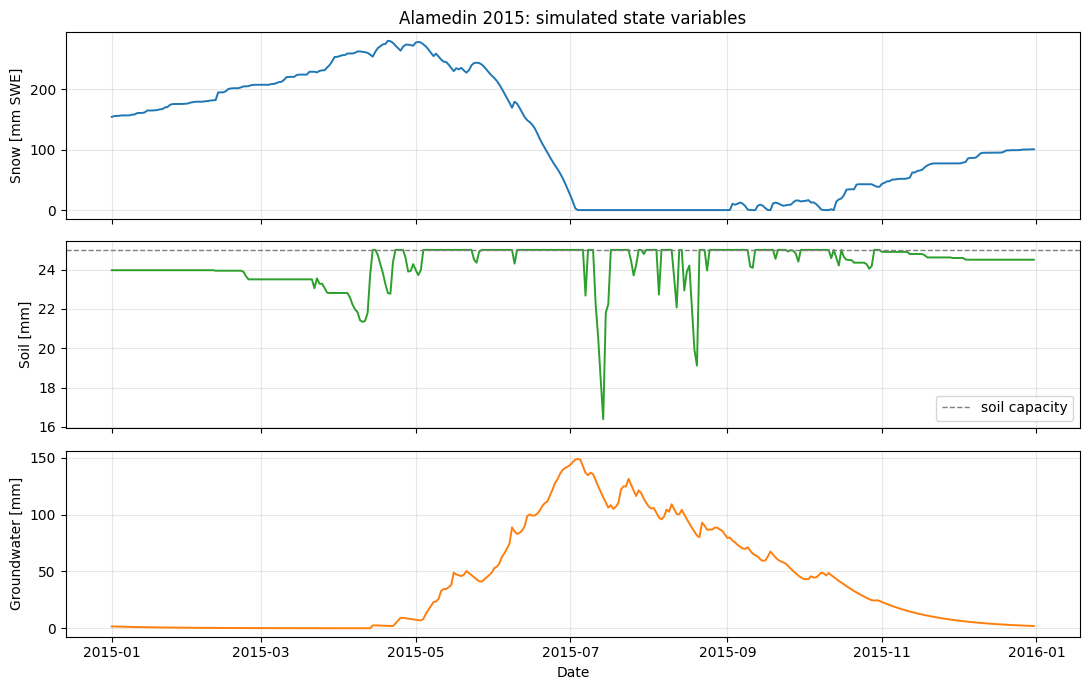

In [26]:
from wat_mod_giz.plots import plot_state_panels

plot_state_panels(
    results_df,
    soil_capacity_mm=params_alamedin.soil_capacity_mm,
    year=2015,
    output_path=figures_dir / "bucket_model_state_panels_2015.png",
)

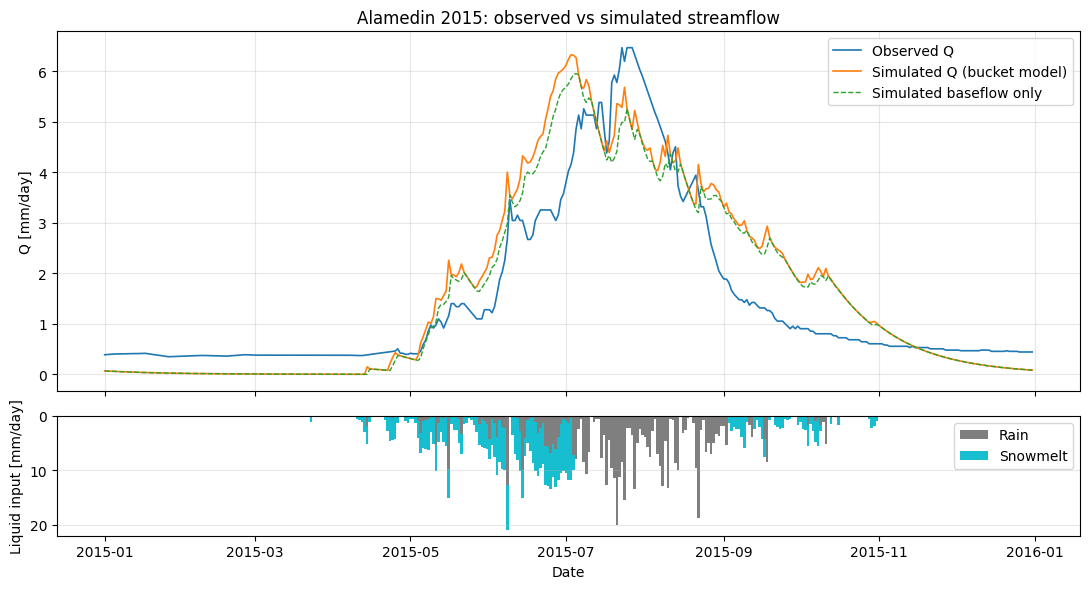

In [27]:
from wat_mod_giz.plots import plot_hydrograph_comparison

plot_hydrograph_comparison(
    results_df,
    q_df_full,
    year=2015,
    output_path=figures_dir / "bucket_model_hydrograph_comparison_2015.png",
)

In [23]:
year_to_plot = 2015
results_2015_df = results_df.loc[results_df["date"].dt.year == year_to_plot]
q_2015_df = q_df_full.loc[
    (q_df_full["date"].dt.year == year_to_plot) & (q_df_full["q_status"] == "observed")
]
sim_peak = results_2015_df["total_runoff_mm"].max()
sim_peak_date = results_2015_df.loc[results_2015_df["total_runoff_mm"].idxmax(), "date"].date()
obs_peak = q_2015_df["q_mm_clean"].max()
obs_peak_date = q_2015_df.loc[q_2015_df["q_mm_clean"].idxmax(), "date"].date()
print(f"Simulated peak: {sim_peak:.2f} mm/day on {sim_peak_date}")
print(f"Observed peak:  {obs_peak:.2f} mm/day on {obs_peak_date}")
print(f"Simulated {year_to_plot} Q total: {results_2015_df['total_runoff_mm'].sum():.1f} mm")
print(f"Observed {year_to_plot} Q total:  {q_2015_df['q_mm_clean'].sum():.1f} mm")

Simulated peak: 7.02 mm/day on 2015-06-08
Observed peak:  6.47 mm/day on 2015-07-23
Simulated 2015 Q total: 619.6 mm
Observed 2015 Q total:  540.9 mm


### Flow-Duration Curves: Low-Flow and Extremes Diagnosis

A single flow-duration curve can hide mismatches. Plotting discharge on a log scale stretches the low-flow end (right side of the curve) and reveals whether baseflow is reproduced. Plotting exceedance probability on a log scale stretches the extremes (left side of the curve) and reveals whether the biggest events are captured.

Together, the two panels are one of the standard first diagnostics for any hydrological model — if the simulated FDC lies on top of the observed FDC in both panels, the model reproduces the *regime*, not just the mean.

We compute both FDCs on the full overlap period (6209 observed days), not just 2015, because a flow-duration curve is a statistic over the full record.

### Кривые обеспеченности: диагностика низких расходов и экстремумов

Одна кривая обеспеченности может скрывать расхождения. Построение расхода в логарифмическом масштабе растягивает низкорасходный конец (правую сторону кривой) и показывает, воспроизводится ли baseflow. Построение вероятности превышения в логарифмическом масштабе растягивает экстремумы (левую сторону кривой) и показывает, захвачены ли крупнейшие события.

Вместе две панели — одна из стандартных первых диагностик для любой гидрологической модели: если смоделированная FDC лежит поверх наблюденной FDC на обеих панелях, модель воспроизводит *режим*, а не только среднее.

Мы вычисляем обе FDC на полном периоде перекрытия (6209 наблюденных дней), а не только на 2015 годе, потому что кривая обеспеченности — статистика по всему ряду.


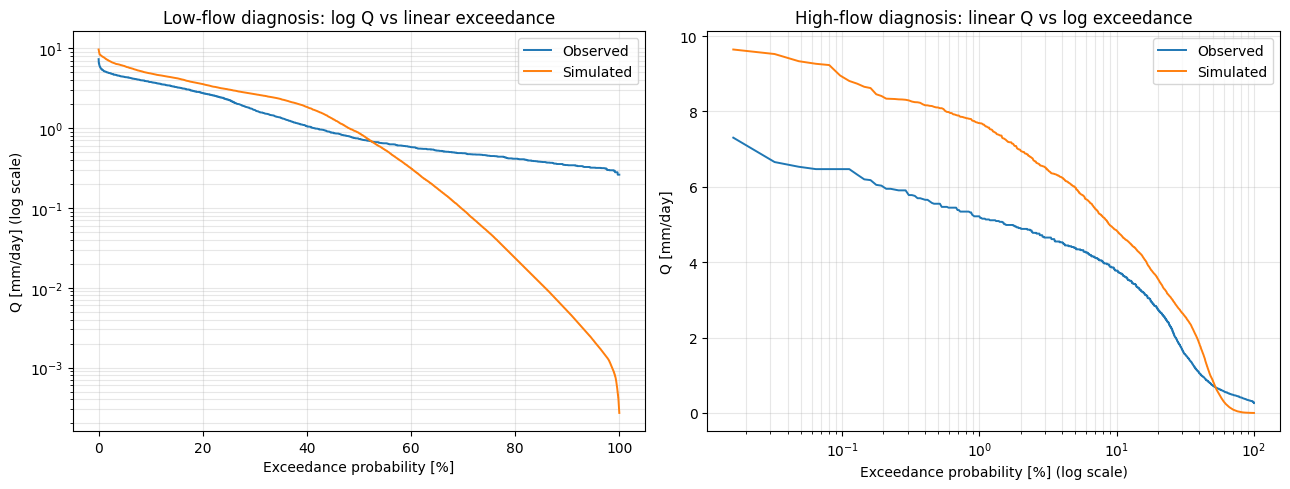

In [24]:
from wat_mod_giz.plots import plot_flow_duration_curves

plot_flow_duration_curves(
    results_df,
    q_df,
    output_path=figures_dir / "alamedin_fdc_comparison.png",
)

## Wrap-Up

You can now:

- define a `Catchment` dataclass for the fixed geographical properties of a basin
- define a `Parameters` dataclass for a five-field calibratable parameter set, with unit-suffixed field names
- define a `State` dataclass for the three storages of a bucket model (`snow_mm`, `soil_mm`, `groundwater_mm`), with sensible defaults
- write pure process functions for the four hydrological building blocks: precipitation partitioning, snowmelt, evapotranspiration, and the soil water balance
- reuse the linear reservoir from notebook 07 as `update_groundwater`, the fifth process function
- chain the five process functions into a single pure `step` that takes `(state, params, precip_mm, temp_degc, pet_mm)` and returns a new state plus a dict of fluxes
- write a driver function that loops `step` over a forcing DataFrame and returns a full-simulation DataFrame
- run the full bucket model on 44 years of daily Alamedin forcing in under a second
- plot simulated state variables and compare simulated to observed streamflow on a plausible uncalibrated parameter set
- use flow-duration curves with two panel layouts to separately diagnose low-flow and high-flow performance
- describe what you would need to add to this model before calibrating it against observed streamflow

## Итоги

Теперь вы умеете:

- определять dataclass `Catchment` для фиксированных географических свойств бассейна
- определять dataclass `Parameters` для калибруемого набора из пяти полей с именами полей, содержащими единицы
- определять dataclass `State` для трех хранилищ bucket-модели (`snow_mm`, `soil_mm`, `groundwater_mm`) с разумными значениями по умолчанию
- писать чистые процессные функции для четырех гидрологических блоков: разделение осадков, снеготаяние, эвапотранспирация и водный баланс почвы
- повторно использовать линейный резервуар из ноутбука 07 как `update_groundwater`, пятую процессную функцию
- соединять пять процессных функций в один чистый `step`, который принимает `(state, params, precip_mm, temp_degc, pet_mm)` и возвращает новое состояние плюс словарь fluxes
- писать функцию-драйвер, которая циклом применяет `step` к DataFrame форсинга и возвращает DataFrame полной симуляции
- запускать полную bucket-модель на 44 годах ежедневного форсинга Аламедина меньше чем за секунду
- строить графики смоделированных переменных состояния и сравнивать смоделированный сток с наблюденным на правдоподобном некалиброванном наборе параметров
- использовать кривые обеспеченности с двухпанельной компоновкой, чтобы отдельно диагностировать низкие и высокие расходы
- описывать, что нужно добавить в модель перед калибровкой по наблюденному стоку


### The arc

Looking back across the whole course:

- **Notebooks 01–04** — Python as a language: values, collections, control flow, functions, type hints.
- **Notebooks 05–06** — Python as a hydrology tool: `pandas` for time series, `matplotlib` for figures, the Alamedin and Ala-Archa forcings and discharge records.
- **Notebook 07** — The minimum non-trivial state-space model: one bucket, one parameter, one state variable. The move from "scripts that process data" to "programs that simulate a system."
- **Notebook 08** (this one) — The full bucket model: three buckets, five parameters, three state variables. The same state-space pattern as notebook 07, composed.

The throughline is type-driven decomposition. Every step of the course added pressure to represent domain concepts with named types: a basin as a `Basin` dataclass, a parameter set as a `Parameters` dataclass, a bucket state as a `State` dataclass. The payoff is that the code reads top-to-bottom as hydrology, not as indexing.

### Дуга курса

Если оглянуться на весь курс:

- **Ноутбуки 01–04** — Python как язык: значения, коллекции, поток управления, функции, подсказки типов.
- **Ноутбуки 05–06** — Python как инструмент гидрологии: `pandas` для временных рядов, `matplotlib` для фигур, форсинги и ряды расходов Аламедина и Ала-Арчи.
- **Ноутбук 07** — минимальная нетривиальная модель пространства состояний: один bucket, один параметр, одна переменная состояния. Переход от «скриптов, которые обрабатывают данные» к «программам, которые симулируют систему».
- **Ноутбук 08** (этот) — полная bucket-модель: три bucket, пять параметров, три переменные состояния. Тот же шаблон пространства состояний, что в ноутбуке 07, но составленный из частей.

Сквозная линия — декомпозиция, управляемая типами. Каждый шаг курса усиливал необходимость представлять доменные понятия именованными типами: бассейн как dataclass `Basin`, набор параметров как dataclass `Parameters`, состояние bucket как dataclass `State`. Выигрыш в том, что код читается сверху вниз как гидрология, а не как индексирование.


### Next steps in the course

Three directions from here.

**Calibration.** The `params_alamedin` values used in this notebook were plausible first guesses. A proper calibration fits these five parameters against observed discharge using an objective function (Kling-Gupta efficiency or similar) and a global optimiser. With calibrated parameters, the simulated hydrograph tracks the observed record much more tightly than what you just saw — and both panels of the FDC line up.

**A second catchment.** Ala-Archa is next door to Alamedin, at a similar elevation, with similar forcing. Running the same model on Ala-Archa with independently calibrated parameters — and comparing the two parameter sets — is the first step toward regionalisation.

**Parameter sensitivity.** Each of the five parameters controls a specific part of the hydrograph: `melt_factor_mm_per_c_day` controls the shape of the spring melt pulse, `soil_capacity_mm` controls the split between storm runoff and ET loss, `groundwater_k_days` controls the recession slope. A one-at-a-time sweep of each parameter across a plausible range, plotting the simulated hydrograph each time, makes these controls very concrete.

All three use the `step` and `run_bucket_model` you just wrote — unchanged. That is the point of a clean model interface.

### Следующие шаги курса

Три направления отсюда.

**Калибровка.** Значения `params_alamedin`, использованные в этом ноутбуке, были правдоподобными первыми догадками. Настоящая калибровка подгоняет эти пять параметров под наблюденный расход с помощью целевой функции (эффективность Клинг-Гупта или похожая) и глобального оптимизатора. С калиброванными параметрами смоделированный гидрограф следует наблюденному ряду намного плотнее, чем то, что вы только что видели, и обе панели FDC совпадают.

**Второй водосбор.** Ала-Арча находится рядом с Аламедином, на похожей высоте и с похожим форсингом. Запуск той же модели на Ала-Арче с независимо калиброванными параметрами — и сравнение двух наборов параметров — первый шаг к регионализации.

**Чувствительность параметров.** Каждый из пяти параметров управляет определенной частью гидрографа: `melt_factor_mm_per_c_day` управляет формой весеннего импульса таяния, `soil_capacity_mm` управляет разделением между storm runoff и потерями ET, `groundwater_k_days` управляет наклоном рецессии. Однофакторный перебор каждого параметра по правдоподобному диапазону с построением смоделированного гидрографа каждый раз делает эти управления очень конкретными.

Все три направления используют `step` и `run_bucket_model`, которые вы только что написали, — без изменений. В этом смысл чистого интерфейса модели.
